# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [8]:
print("LabelEncoder convierte cada categoría en un número entero.")
print("Ejemplo: male/female se convierten en 0 y 1.")
print()
print("OneHotEncoder crea una columna nueva por cada categoría.")
print("Ejemplo: embarked_C, embarked_Q, embarked_S.")

LabelEncoder convierte cada categoría en un número entero.
Ejemplo: male/female se convierten en 0 y 1.

OneHotEncoder crea una columna nueva por cada categoría.
Ejemplo: embarked_C, embarked_Q, embarked_S.


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

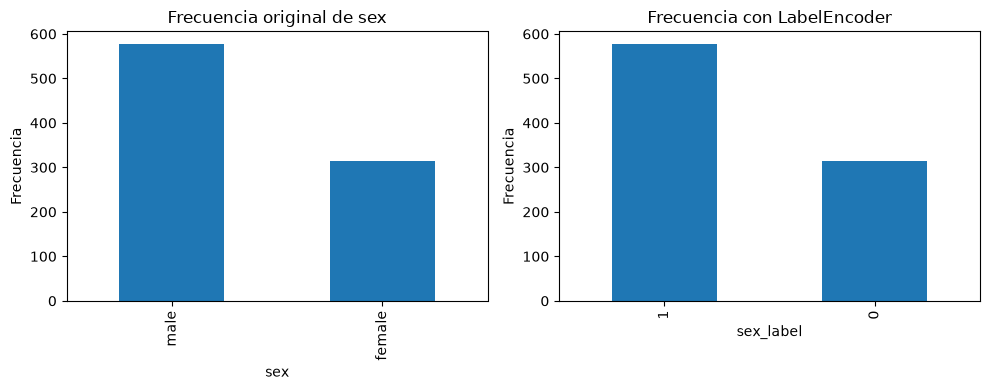

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

data['sex'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Frecuencia original de sex')
axes[0].set_xlabel('sex')
axes[0].set_ylabel('Frecuencia')

data['sex_label'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Frecuencia con LabelEncoder')
axes[1].set_xlabel('sex_label')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [12]:
class_onehot = pd.get_dummies(data['class'], prefix='class')

class_onehot.head()


# OneHotEncoder es útil para variables categóricas nominales porque crea una columna por categoría y 
# evita que el modelo interprete un orden falso entre las clases. 
# En cambio, LabelEncoder asigna números como 0, 1 y 2, lo cual puede hacer que el modelo 
# piense que una categoría es mayor que otra.

,class_First,class_Second,class_Third
0,False,False,True
1,True,False,False
2,False,False,True
3,True,False,False
4,False,False,True


In [13]:

data = pd.concat([data, class_onehot], axis=1)

data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,sex_label,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,1,False,False,True,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,0,True,False,False,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,0,False,False,True,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,0,False,False,True,True,False,False,True,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,1,False,False,True,False,False,True,False,False,True


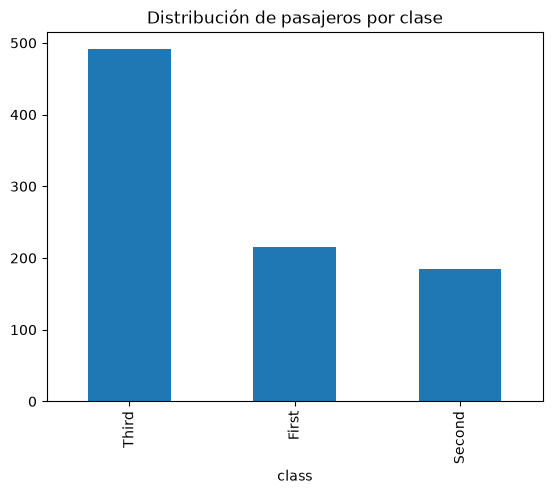

In [15]:
data['class'].value_counts().plot(
    kind='bar',
    title='Distribución de pasajeros por clase'
)

plt.show()

In [14]:
data[['class_First', 'class_Second', 'class_Third']].head()

,class_First,class_First,class_Second,class_Second,class_Third,class_Third
0,False,False,False,False,True,True
1,True,True,False,False,False,False
2,False,False,False,False,True,True
3,True,True,False,False,False,False
4,False,False,False,False,True,True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
# Si fuera a entrenar un modelo de aprendizaje automático, utilizaría OneHotEncoder para las variables categóricas 
# nominales como sex, embarked y class. Este método evita introducir relaciones ordinales artificiales entre 
# categorías y suele producir mejores resultados en modelos que trabajan con distancias o pesos. 
# LabelEncoder es más apropiado cuando las categorías tienen un orden natural, como bajo, medio y alto.